In [2]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

In [99]:
# glacier = 'gulkana'
# site = 'B'
# snowmelt_class = SnowMelt(glacier, site)
# dem_class = DEM(glacier)
# albedo = Albedo(glacier, site)
# dem_class.reproject_to(albedo.ds)
# albedo.plot_map_snowline('2021-07-01', snowmelt_class, dem_class, snowline_var='snowline_elev_m', plot_sites=[site])

In [3]:
fn = 'ddf/{g}{s}_2026_04_15_MO_0.nc'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
for glacier in site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in site_dict[glacier]:
        fn_ds = base_fp + fn.format(g=glacier, s=site)
        ds = xr.open_dataset(fn_ds)

        mb_data = MassBalance(glacier, site, use='benchmark')
        albedo_data = Albedo(glacier, site, use='all')

        # parse model run
        albedo_data.get_model_albedo(ds)
        try:
            mb_data.get_model_mb(ds)
        except:
            for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                all_mod_albedo.append(mod)
                all_meas_albedo.append(meas)
                all_time_albedo.append(t)
            continue

        if len(mb_data.mod) < 2:
            print('insufficient data')
            continue
        elif mb_data.dataset == 'seasonal':
            me_summer, me_winter = mb_data.bias(True)
            if np.abs(me_summer) > 1 or np.abs(me_winter) > 1:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Summer mass balance bias:',me_summer)
                print('Winter mass balance bias:',me_winter)
                print('Albedo bias:',albedo_data.bias())
                print()
                # mb_data.plot_mb()
            else:
                print(glacier, site, 'is good')
        else:
            if np.abs(mb_data.mae()) > 1:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Annual mass balance bias:',mb_data.mae())
                print('Albedo bias:',albedo_data.bias())
                print()
                # mb_data.plot_mb()
            else:
                print(glacier, site, 'is good')
               
        # plot
        # mb_data.plot_mb()
        # albedo_data.plot_timeseries()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

wolverine N is good
wolverine B is good
wolverine EC is good
kahiltna K53 is good
kahiltna K17b is good
kennicott GTL is good
kennicott GTH is good
insufficient data
lemon_creek B has biased mass balance using kp= 1.4230809067903878
Summer mass balance bias: 1.2917010025685494
Winter mass balance bias: -0.4896922680053033
Albedo bias: 0.05195762295536908

lemon_creek C is good
lemon_creek D is good
taku NWB1 is good
taku TKG3 is good
gulkana AU is good
gulkana B is good
gulkana D is good


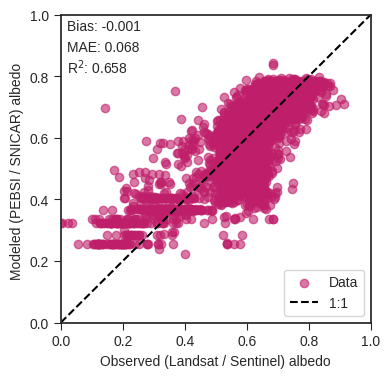

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=colors[4], alpha=0.6) # cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
# ax.set_title('Albedo modeled at Gulkana Glacier')
ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/good_outdated_albedo.png', bbox_inches='tight', dpi=300)
plt.show()

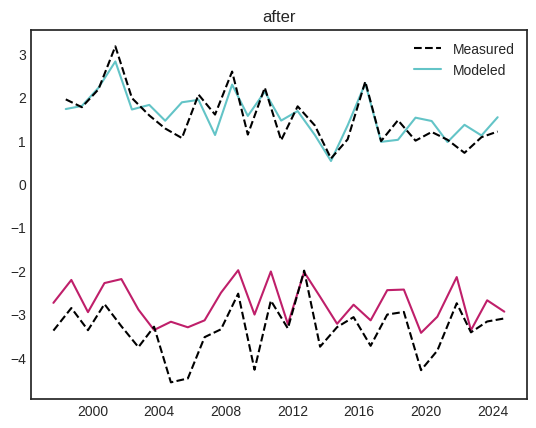

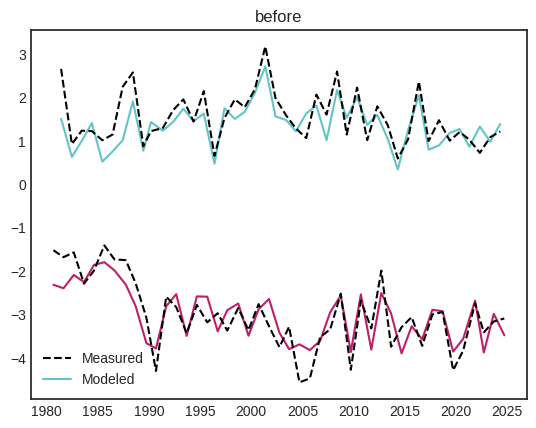

In [4]:
after = xr.open_dataset(base_fp + 'ddf/wolverineB_2026_04_27_check_0.nc')
before = xr.open_dataset(base_fp + 'ddf/wolverineB_2026_04_15_MO_0.nc')

for f, ds in zip(['after','before'], [after, before]):
    mass = MassBalance('wolverine','B')
    mass.get_model_mb(ds)
    fig, ax = mass.plot_mb()
    ax.set_title(f)
    plt.show()


# dates = pd.date_range('2024-03-20','2024-08-20', freq='h')
# after = after.sel(time=dates, layer=0).resample(time='d').mean()
# before = before.sel(time=dates, layer=0).resample(time='d').mean()
# plt.plot(after.time, after.layerBC, label='After fix')
# plt.plot(before.time, before.layerBC, label='Before fix')
# plt.title('BC')
# plt.show()

# plt.plot(after.time, after.layergrainsize, label='After fix')
# plt.plot(before.time, before.layergrainsize, label='Before fix')
# plt.title('Grain size')
# plt.legend()
# plt.show()

# plt.plot(after.time, after.albedo, label='After fix')
# plt.plot(before.time, before.albedo, label='Before fix')
# plt.title('Albedo')
# plt.legend()
# plt.show()

In [5]:
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    ds_sw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/SWGDN_{coords}.nc')
    ds_bc = ds_bc.assign_coords({'time':ds_bc.time.values - pd.Timedelta(hours=8)})
    ds_sw = ds_sw.assign_coords({'time':ds_sw.time.values - pd.Timedelta(hours=8)})

    for site in site_dict[glacier]:
        ds = xr.open_dataset(base_fp+f'ddf/{glacier}{site}_2026_03_19_long_0.nc')
        out_daily = base_fp + f'ddf/{glacier}{site}_df_daily.csv'
        out_hourly = base_fp + f'ddf/{glacier}{site}_df_hourly.csv'
        get_daily_df(ds, ds_bc, ds_sw, output_fn=out_daily, n_rolling_bc=5, n_rolling_pdds=1)
        get_hourly_df(ds, ds_bc, ds_sw, output_fn=out_hourly, n_rolling_bc=5)

Saved wolverine N
Saved wolverine B
Saved wolverine EC
Saved kahiltna K53
Saved kahiltna K17b
Saved kennicott GTL
Saved kennicott GTH
Saved kennicott KC31
Saved lemon_creek B
Saved lemon_creek C
Saved lemon_creek D
Saved taku NWB1
Saved taku MG1
Saved taku TKG3
Saved gulkana AU
Saved gulkana B
Saved gulkana D


In [25]:
coords = '63.5_-145.6'
df_before = pd.read_csv(base_fp + 'ddf/gulkanaD_df_hourly.csv')
ds = xr.open_dataset(base_fp + 'ddf/gulkanaD_2026_03_19_long_0.nc')
ds_bcd = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
ds_bcw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
ds_sw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/SWGDN_{coords}.nc')
ds_bc = ds_bc.assign_coords({'time':ds_bc.time.values - pd.Timedelta(hours=8)})
ds_sw = ds_sw.assign_coords({'time':ds_sw.time.values - pd.Timedelta(hours=8)})
ds_new = get_hourly_df(ds, ds_bc, ds_sw)

In [6]:
all_dfs = {'hourly':None, 'daily':None}
for glacier in site_dict:
    for site in site_dict[glacier]:
        for time_res in all_dfs:
            out = base_fp+f'ddf/{glacier}{site}_df_{time_res}.csv'
            df = pd.read_csv(out)
            if 'accum_1d_rolling' in df.columns:
                df = df.rename(columns={'accum_1d_rolling','accum'})
            df['glacier'] = [glacier] * len(df.index)
            df['glaciersite'] = [glacier + site] * len(df.index)
            if all_dfs[time_res] is not None:
                all_dfs[time_res] = pd.concat([all_dfs[time_res], df])
            else:
                all_dfs[time_res] = df
all_dfs['daily'].to_csv(base_fp+'ddf/all_daily_df.csv')
all_dfs['hourly'].to_csv(base_fp+'ddf/all_hourly_df.csv')

In [ ]:
#######################################################################################